In [1]:
from vmc_ising import output_dir, get_config, get_lattice, default_config
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from nqs_playground_helpers import safe_exp
import torch
from pathlib import Path
from collections.abc import Iterable
import jsonlines
import pandas as pd

Running dilated_nns_xors.py


In [25]:
df = (
    read_jsonl_to_df(output_dir.glob("*/results.jsonl"))
    .fillna(keep_serializable(default_config))
)

In [26]:
df.columns

Index(['config_n_samples', 'config_lr', 'config_batch_size',
       'config_weight_decay', 'config_max_iter', 'config_lattice', 'config_J2',
       'config_use_symmetries', 'config_spin_inversion',
       'config_eval_set_max_size', 'config_device', 'config_random_seed',
       'config_dilations', 'config_hidden_channels', 'config_warm_up_overlap',
       'config_sign_update_period', 'config_sign_reconstruction.method',
       'config_sign_reconstruction.number_sweeps', 'config_warm_up.sign_noise',
       'config_log_prob_fn', 'config_kernel_size', 'overlap', '‖∇E‖₂',
       'E_full_delta', 'ipr', 'step', 'E_variance', 'start_timestamp',
       'task_id', 'device', 'warm_up', 'sign_overlap', 'step_since_warm_up',
       'signs_updated', 'signs_updated_at', 'step_since_signs_updated'],
      dtype='object')

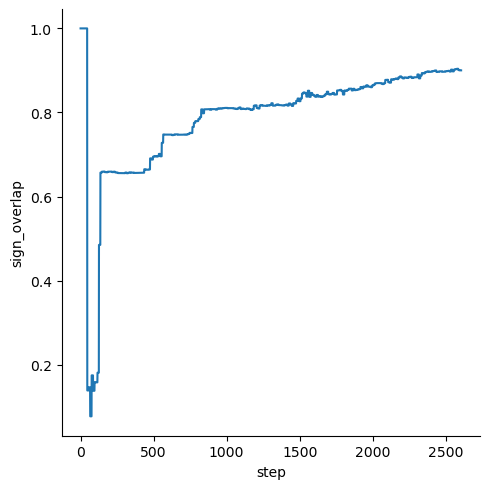

In [29]:
sns.relplot(df.query('task_id == 13'), x='step', y='sign_overlap', kind='line')

In [16]:
df.columns

Index(['config_n_samples', 'config_lr', 'config_batch_size',
       'config_weight_decay', 'config_max_iter', 'config_lattice', 'config_J2',
       'config_use_symmetries', 'config_spin_inversion',
       'config_eval_set_max_size', 'config_device', 'config_random_seed',
       'config_dilations', 'config_hidden_channels', 'config_warm_up_overlap',
       'config_sign_update_period', 'config_sign_reconstruction.method',
       'config_sign_reconstruction.number_sweeps', 'config_warm_up.sign_noise',
       'config_log_prob_fn', 'config_kernel_size', 'overlap', '‖∇E‖₂',
       'E_full_delta', 'ipr', 'step', 'E_variance', 'start_timestamp',
       'task_id', 'device', 'warm_up', 'sign_overlap', 'step_since_warm_up',
       'signs_updated', 'signs_updated_at', 'step_since_signs_updated'],
      dtype='object')

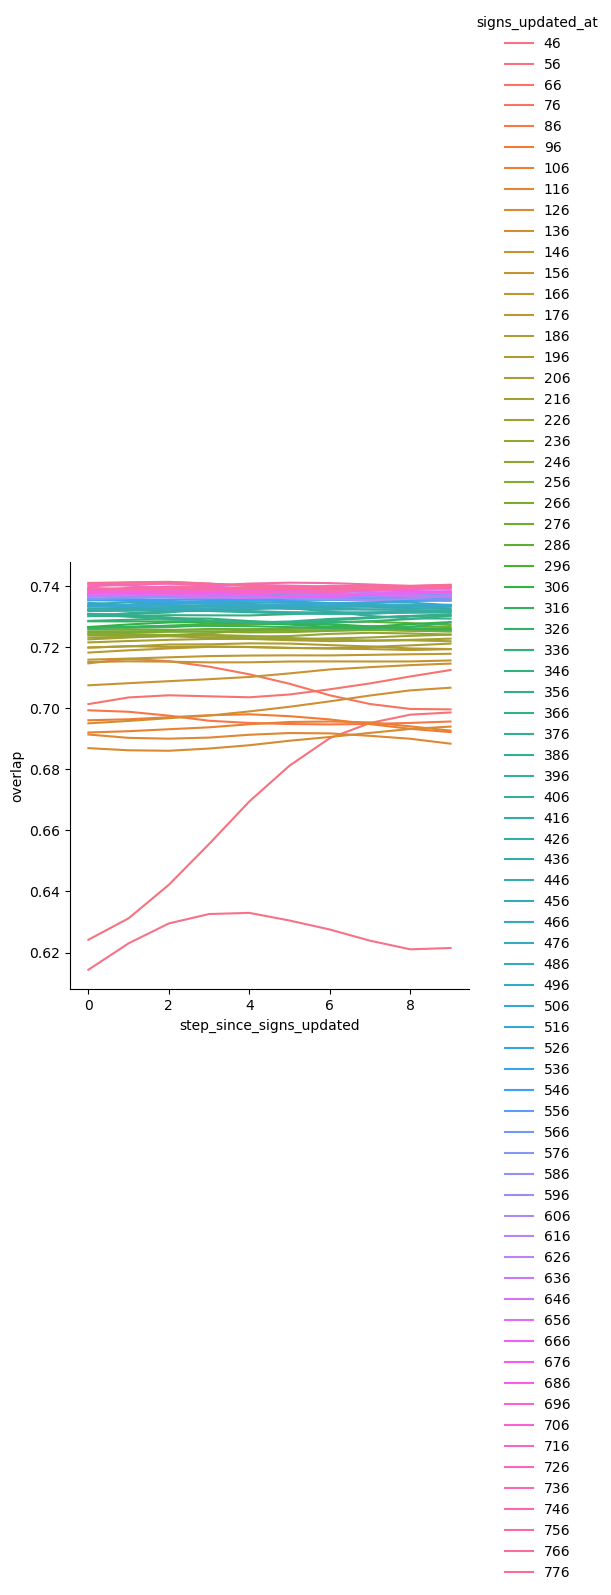

In [22]:
sns.relplot(
    df.query("task_id == 13 and not warm_up").pipe(column_to(str, "signs_updated_at")),
    x="step_since_signs_updated",
    y="overlap",
    hue="signs_updated_at",
    kind='line',
)